# Poly-1 Loss ResNet50 Multi-Seed (52 dan 62)

Notebook ini melanjutkan eksperimen Poly-1 Loss seed 42. Arsitektur, data split, augmentasi, optimizer, scheduler, dan parameter loss dipertahankan. Setiap seed membuat model, optimizer, scheduler, checkpoint, threshold, dan hasil test yang terpisah.


In [1]:
from pathlib import Path
import gc
import json
import random
import shutil

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from PIL import Image

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.optim import AdamW
from torch.optim.lr_scheduler import ReduceLROnPlateau
from torch.utils.data import DataLoader, Dataset
from torchvision import transforms
from torchvision.models import ResNet50_Weights, resnet50

from sklearn.metrics import (
    accuracy_score,
    f1_score,
    hamming_loss,
    multilabel_confusion_matrix,
    precision_recall_fscore_support,
    roc_auc_score,
)

SEEDS = [52, 62]
BATCH_SIZE = 16
NUM_WORKERS = 2
IMAGE_SIZE = 224
LEARNING_RATE = 1e-4
WEIGHT_DECAY = 1e-4
MAX_EPOCHS = 30
EARLY_STOPPING_PATIENCE = 7
DROPOUT = 0.30

POLY_EPSILON = 1.0

LABELS = ["N", "D", "G", "C", "A", "H", "M", "O"]
DISEASE_LABELS = ["D", "G", "C", "A", "H", "M"]
DISEASE_INDICES = [LABELS.index(label) for label in DISEASE_LABELS]

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

DATASET_DIR = Path(
    "/kaggle/input/datasets/kevinardhana/"
    "odir-5k-patient-level-multi-label-fundus-dataset"
)
IMAGE_DIR = DATASET_DIR / "Training Images" / "Training Images"
TRAIN_CSV = DATASET_DIR / "train.csv"
VALID_CSV = DATASET_DIR / "validation.csv"
TEST_CSV = DATASET_DIR / "test.csv"

OUTPUT_DIR = Path("/kaggle/working/polyloss_resnet50_multiseed")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)


def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)


def seed_worker(worker_id):
    worker_seed = torch.initial_seed() % (2**32)
    random.seed(worker_seed)
    np.random.seed(worker_seed)


train_df = pd.read_csv(TRAIN_CSV)
valid_df = pd.read_csv(VALID_CSV)
test_df = pd.read_csv(TEST_CSV)

assert len(train_df) == 2450
assert len(valid_df) == 525
assert len(test_df) == 525
assert set(train_df["patient_id"]).isdisjoint(valid_df["patient_id"])
assert set(train_df["patient_id"]).isdisjoint(test_df["patient_id"])
assert set(valid_df["patient_id"]).isdisjoint(test_df["patient_id"])

positive_counts = train_df[LABELS].sum()
negative_counts = len(train_df) - positive_counts
class_distribution_table = pd.DataFrame(
    {
        "label": LABELS,
        "positif_train": positive_counts.values.astype(int),
        "negatif_train": negative_counts.values.astype(int),
    }
)

train_transform = transforms.Compose(
    [
        transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
        transforms.RandomHorizontalFlip(p=0.5),
        transforms.RandomRotation(15),
        transforms.ColorJitter(
            brightness=0.1,
            contrast=0.1,
            saturation=0.1,
            hue=0.02,
        ),
        transforms.ToTensor(),
        transforms.Normalize(
            mean=[0.485, 0.456, 0.406],
            std=[0.229, 0.224, 0.225],
        ),
    ]
)

eval_transform = transforms.Compose(
    [
        transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
        transforms.ToTensor(),
        transforms.Normalize(
            mean=[0.485, 0.456, 0.406],
            std=[0.229, 0.224, 0.225],
        ),
    ]
)


class FundusPairDataset(Dataset):
    def __init__(self, dataframe, image_dir, transform):
        self.dataframe = dataframe.reset_index(drop=True)
        self.image_dir = Path(image_dir)
        self.transform = transform

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, index):
        row = self.dataframe.iloc[index]
        left_image = Image.open(self.image_dir / row["left_image"]).convert("RGB")
        right_image = Image.open(self.image_dir / row["right_image"]).convert("RGB")

        return {
            "left_image": self.transform(left_image),
            "right_image": self.transform(right_image),
            "labels": torch.tensor(
                row[LABELS].values.astype(np.float32),
                dtype=torch.float32,
            ),
            "patient_id": int(row["patient_id"]),
        }


class SharedResNet50(nn.Module):
    def __init__(self, num_labels=8, dropout=0.30):
        super().__init__()
        self.backbone = resnet50(weights=ResNet50_Weights.IMAGENET1K_V2)
        feature_dim = self.backbone.fc.in_features
        self.backbone.fc = nn.Identity()
        self.classifier = nn.Sequential(
            nn.Dropout(p=dropout),
            nn.Linear(feature_dim * 2, num_labels),
        )

    def forward(self, left_image, right_image):
        left_features = self.backbone(left_image)
        right_features = self.backbone(right_image)
        combined_features = torch.cat([left_features, right_features], dim=1)
        return self.classifier(combined_features)


class Poly1Loss(nn.Module):
    def __init__(self, epsilon=1.0):
        super().__init__()
        self.epsilon = epsilon

    def forward(self, logits, targets):
        bce_loss = F.binary_cross_entropy_with_logits(
            logits,
            targets,
            reduction="none",
        )
        probabilities = torch.sigmoid(logits)
        p_t = (
            probabilities * targets
            + (1.0 - probabilities) * (1.0 - targets)
        )
        poly_term = self.epsilon * (1.0 - p_t)
        return (bce_loss + poly_term).mean()


train_dataset = FundusPairDataset(train_df, IMAGE_DIR, train_transform)
valid_dataset = FundusPairDataset(valid_df, IMAGE_DIR, eval_transform)
test_dataset = FundusPairDataset(test_df, IMAGE_DIR, eval_transform)

valid_loader = DataLoader(
    valid_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=DEVICE.type == "cuda",
)
test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=DEVICE.type == "cuda",
)


def build_train_loader(seed):
    generator = torch.Generator()
    generator.manual_seed(seed)
    return DataLoader(
        train_dataset,
        batch_size=BATCH_SIZE,
        shuffle=True,
        num_workers=NUM_WORKERS,
        pin_memory=DEVICE.type == "cuda",
        worker_init_fn=seed_worker,
        generator=generator,
    )


def build_model():
    return SharedResNet50(num_labels=len(LABELS), dropout=DROPOUT).to(DEVICE)


def build_criterion():
    return Poly1Loss(epsilon=POLY_EPSILON)


def train_one_epoch(model, loader, criterion, optimizer):
    model.train()
    total_loss = 0.0
    total_samples = 0

    for batch in loader:
        left_images = batch["left_image"].to(DEVICE, non_blocking=True)
        right_images = batch["right_image"].to(DEVICE, non_blocking=True)
        labels = batch["labels"].to(DEVICE, non_blocking=True)

        optimizer.zero_grad(set_to_none=True)
        logits = model(left_images, right_images)
        loss = criterion(logits, labels)
        loss.backward()
        optimizer.step()

        batch_size = labels.size(0)
        total_loss += loss.item() * batch_size
        total_samples += batch_size

    return total_loss / total_samples


@torch.no_grad()
def evaluate_at_threshold(model, loader, criterion, threshold=0.5):
    model.eval()
    total_loss = 0.0
    total_samples = 0
    all_labels = []
    all_probabilities = []

    for batch in loader:
        left_images = batch["left_image"].to(DEVICE, non_blocking=True)
        right_images = batch["right_image"].to(DEVICE, non_blocking=True)
        labels = batch["labels"].to(DEVICE, non_blocking=True)

        logits = model(left_images, right_images)
        loss = criterion(logits, labels)
        probabilities = torch.sigmoid(logits)

        batch_size = labels.size(0)
        total_loss += loss.item() * batch_size
        total_samples += batch_size
        all_labels.append(labels.cpu().numpy())
        all_probabilities.append(probabilities.cpu().numpy())

    true_labels = np.concatenate(all_labels, axis=0)
    probabilities = np.concatenate(all_probabilities, axis=0)
    predictions = (probabilities >= threshold).astype(np.int32)

    return {
        "loss": total_loss / total_samples,
        "macro_f1": float(
            f1_score(true_labels, predictions, average="macro", zero_division=0)
        ),
        "micro_f1": float(
            f1_score(true_labels, predictions, average="micro", zero_division=0)
        ),
    }


@torch.no_grad()
def collect_predictions(model, loader):
    model.eval()
    patient_ids = []
    all_labels = []
    all_probabilities = []

    for batch in loader:
        left_images = batch["left_image"].to(DEVICE, non_blocking=True)
        right_images = batch["right_image"].to(DEVICE, non_blocking=True)
        probabilities = torch.sigmoid(model(left_images, right_images))

        patient_ids.extend(batch["patient_id"].cpu().numpy().tolist())
        all_labels.append(batch["labels"].cpu().numpy())
        all_probabilities.append(probabilities.cpu().numpy())

    return (
        np.asarray(patient_ids),
        np.concatenate(all_labels, axis=0),
        np.concatenate(all_probabilities, axis=0),
    )


print("Device:", DEVICE)
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
print("Seed yang akan dijalankan:", SEEDS)
print("Train / validation / test:", len(train_df), len(valid_df), len(test_df))
print("Poly-1 epsilon:", POLY_EPSILON)
display(class_distribution_table)


Device: cuda
GPU: Tesla T4
Seed yang akan dijalankan: [52, 62]
Train / validation / test: 2450 525 525
Poly-1 epsilon: 1.0


,label,positif_train,negatif_train
0,N,796,1654
1,D,790,1660
2,G,151,2299
3,C,148,2302
4,A,115,2335
5,H,72,2378
6,M,122,2328
7,O,685,1765


In [2]:
training_runs = {}

for seed in SEEDS:
    print(f"\nMemulai training seed {seed}")
    set_seed(seed)

    seed_dir = OUTPUT_DIR / f"seed_{seed}"
    seed_dir.mkdir(parents=True, exist_ok=True)
    checkpoint_path = seed_dir / "best_polyloss_resnet50.pt"
    history_path = seed_dir / "training_history.json"

    train_loader = build_train_loader(seed)
    model = build_model()
    criterion = build_criterion()
    optimizer = AdamW(
        model.parameters(),
        lr=LEARNING_RATE,
        weight_decay=WEIGHT_DECAY,
    )
    scheduler = ReduceLROnPlateau(
        optimizer,
        mode="max",
        factor=0.5,
        patience=2,
    )

    history = []
    best_macro_f1 = -1.0
    best_epoch = 0
    patience_counter = 0

    for epoch in range(1, MAX_EPOCHS + 1):
        train_loss = train_one_epoch(model, train_loader, criterion, optimizer)
        validation_result = evaluate_at_threshold(
            model,
            valid_loader,
            criterion,
            threshold=0.5,
        )

        scheduler.step(validation_result["macro_f1"])
        current_lr = optimizer.param_groups[0]["lr"]
        epoch_result = {
            "epoch": epoch,
            "train_loss": float(train_loss),
            "validation_loss": float(validation_result["loss"]),
            "validation_macro_f1": float(validation_result["macro_f1"]),
            "validation_micro_f1": float(validation_result["micro_f1"]),
            "learning_rate": float(current_lr),
        }
        history.append(epoch_result)

        print(
            f"Seed {seed} | Epoch {epoch:02d}/{MAX_EPOCHS} | "
            f"train loss: {train_loss:.4f} | "
            f"val loss: {validation_result['loss']:.4f} | "
            f"val Macro-F1: {validation_result['macro_f1']:.4f} | "
            f"val Micro-F1: {validation_result['micro_f1']:.4f} | "
            f"lr: {current_lr:.6f}"
        )

        if validation_result["macro_f1"] > best_macro_f1:
            best_macro_f1 = validation_result["macro_f1"]
            best_epoch = epoch
            patience_counter = 0
            torch.save(
                {
                    "epoch": epoch,
                    "model_state_dict": model.state_dict(),
                    "optimizer_state_dict": optimizer.state_dict(),
                    "best_macro_f1": float(best_macro_f1),
                    "labels": LABELS,
                    "poly_epsilon": POLY_EPSILON,
                    "image_size": IMAGE_SIZE,
                    "dropout": DROPOUT,
                    "learning_rate": LEARNING_RATE,
                    "weight_decay": WEIGHT_DECAY,
                    "seed": seed,
                },
                checkpoint_path,
            )
            print("Checkpoint terbaik disimpan.")
        else:
            patience_counter += 1

        with open(history_path, "w", encoding="utf-8") as file:
            json.dump(history, file, indent=2)

        if patience_counter >= EARLY_STOPPING_PATIENCE:
            print(
                f"Early stopping pada epoch {epoch}. "
                f"Checkpoint terbaik: epoch {best_epoch}."
            )
            break

    training_runs[seed] = {
        "seed_dir": seed_dir,
        "checkpoint_path": checkpoint_path,
        "history": history,
        "best_epoch": best_epoch,
        "best_macro_f1_at_050": float(best_macro_f1),
    }

    del model, optimizer, scheduler, train_loader
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

print("\nSeluruh training Poly-1 Loss multi-seed selesai.")



Memulai training seed 52
Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 135MB/s]


Seed 52 | Epoch 01/30 | train loss: 0.5688 | val loss: 0.4913 | val Macro-F1: 0.2120 | val Micro-F1: 0.2487 | lr: 0.000100
Checkpoint terbaik disimpan.
Seed 52 | Epoch 02/30 | train loss: 0.4645 | val loss: 0.4782 | val Macro-F1: 0.3225 | val Micro-F1: 0.3798 | lr: 0.000100
Checkpoint terbaik disimpan.
Seed 52 | Epoch 03/30 | train loss: 0.4341 | val loss: 0.4559 | val Macro-F1: 0.3537 | val Micro-F1: 0.4290 | lr: 0.000100
Checkpoint terbaik disimpan.
Seed 52 | Epoch 04/30 | train loss: 0.4036 | val loss: 0.4389 | val Macro-F1: 0.4330 | val Micro-F1: 0.4638 | lr: 0.000100
Checkpoint terbaik disimpan.
Seed 52 | Epoch 05/30 | train loss: 0.3776 | val loss: 0.4225 | val Macro-F1: 0.4976 | val Micro-F1: 0.5081 | lr: 0.000100
Checkpoint terbaik disimpan.
Seed 52 | Epoch 06/30 | train loss: 0.3455 | val loss: 0.4417 | val Macro-F1: 0.4614 | val Micro-F1: 0.5056 | lr: 0.000100
Seed 52 | Epoch 07/30 | train loss: 0.3237 | val loss: 0.4429 | val Macro-F1: 0.5022 | val Micro-F1: 0.4891 | lr: 0.0

In [3]:
evaluation_runs = {}
threshold_candidates = np.arange(0.05, 0.96, 0.01)

for seed in SEEDS:
    print(f"\nEvaluasi validation dan test seed {seed}")
    run = training_runs[seed]
    checkpoint = torch.load(
        run["checkpoint_path"],
        map_location=DEVICE,
        weights_only=False,
    )
    model = build_model()
    model.load_state_dict(checkpoint["model_state_dict"])

    (
        validation_patient_ids,
        validation_labels,
        validation_probabilities,
    ) = collect_predictions(model, valid_loader)

    best_thresholds = []
    best_validation_f1 = []

    for label_index in range(len(LABELS)):
        label_scores = []
        for threshold in threshold_candidates:
            label_predictions = (
                validation_probabilities[:, label_index] >= threshold
            ).astype(np.int32)
            label_scores.append(
                f1_score(
                    validation_labels[:, label_index],
                    label_predictions,
                    zero_division=0,
                )
            )

        best_index = int(np.argmax(label_scores))
        best_thresholds.append(float(threshold_candidates[best_index]))
        best_validation_f1.append(float(label_scores[best_index]))

    best_thresholds = np.asarray(best_thresholds, dtype=np.float32)
    default_validation_predictions = (
        validation_probabilities >= 0.5
    ).astype(np.int32)
    tuned_validation_predictions = (
        validation_probabilities >= best_thresholds
    ).astype(np.int32)

    default_validation_macro_f1 = f1_score(
        validation_labels,
        default_validation_predictions,
        average="macro",
        zero_division=0,
    )
    tuned_validation_macro_f1 = f1_score(
        validation_labels,
        tuned_validation_predictions,
        average="macro",
        zero_division=0,
    )

    threshold_table = pd.DataFrame(
        {
            "label": LABELS,
            "threshold_terbaik": best_thresholds,
            "f1_validation": best_validation_f1,
            "jumlah_positif_validation": validation_labels.sum(axis=0).astype(int),
        }
    )
    threshold_path = run["seed_dir"] / "best_thresholds.json"
    with open(threshold_path, "w", encoding="utf-8") as file:
        json.dump(
            {
                "seed": seed,
                "checkpoint_epoch": int(checkpoint["epoch"]),
                "default_validation_macro_f1": float(default_validation_macro_f1),
                "tuned_validation_macro_f1": float(tuned_validation_macro_f1),
                "thresholds": {
                    label: float(threshold)
                    for label, threshold in zip(LABELS, best_thresholds)
                },
                "validation_f1_per_label": {
                    label: float(score)
                    for label, score in zip(LABELS, best_validation_f1)
                },
            },
            file,
            indent=2,
        )

    test_patient_ids, test_labels, test_probabilities = collect_predictions(
        model,
        test_loader,
    )
    test_predictions = (test_probabilities >= best_thresholds).astype(np.int32)

    test_macro_f1 = f1_score(
        test_labels,
        test_predictions,
        average="macro",
        zero_division=0,
    )
    test_micro_f1 = f1_score(
        test_labels,
        test_predictions,
        average="micro",
        zero_division=0,
    )
    disease_macro_f1 = f1_score(
        test_labels[:, DISEASE_INDICES],
        test_predictions[:, DISEASE_INDICES],
        average="macro",
        zero_division=0,
    )
    test_macro_auroc = roc_auc_score(
        test_labels,
        test_probabilities,
        average="macro",
    )
    test_hamming_loss = hamming_loss(test_labels, test_predictions)
    test_subset_accuracy = accuracy_score(test_labels, test_predictions)

    precision, recall, label_f1, support = precision_recall_fscore_support(
        test_labels,
        test_predictions,
        average=None,
        zero_division=0,
    )
    label_auroc = [
        roc_auc_score(test_labels[:, index], test_probabilities[:, index])
        for index in range(len(LABELS))
    ]
    confusion_matrices = multilabel_confusion_matrix(test_labels, test_predictions)

    per_label_results = []
    for index, label_name in enumerate(LABELS):
        tn, fp, fn, tp = confusion_matrices[index].ravel()
        per_label_results.append(
            {
                "label": label_name,
                "precision": float(precision[index]),
                "recall": float(recall[index]),
                "f1_score": float(label_f1[index]),
                "auroc": float(label_auroc[index]),
                "support": int(support[index]),
                "threshold": float(best_thresholds[index]),
                "TN": int(tn),
                "FP": int(fp),
                "FN": int(fn),
                "TP": int(tp),
            }
        )

    per_label_table = pd.DataFrame(per_label_results)
    test_summary = {
        "loss_function": "Poly-1 Loss",
        "backbone": "ResNet50",
        "seed": seed,
        "poly_epsilon": POLY_EPSILON,
        "checkpoint_epoch": int(checkpoint["epoch"]),
        "validation_macro_f1": float(tuned_validation_macro_f1),
        "test_macro_f1": float(test_macro_f1),
        "test_micro_f1": float(test_micro_f1),
        "test_six_disease_macro_f1": float(disease_macro_f1),
        "test_macro_auroc": float(test_macro_auroc),
        "test_hamming_loss": float(test_hamming_loss),
        "test_subset_accuracy": float(test_subset_accuracy),
    }

    with open(run["seed_dir"] / "test_summary.json", "w", encoding="utf-8") as file:
        json.dump(test_summary, file, indent=2)
    per_label_table.to_csv(
        run["seed_dir"] / "test_metrics_per_label.csv",
        index=False,
    )
    class_distribution_table.to_csv(
        run["seed_dir"] / "class_distribution.csv",
        index=False,
    )

    prediction_data = {"patient_id": test_patient_ids}
    for index, label_name in enumerate(LABELS):
        prediction_data[f"true_{label_name}"] = test_labels[:, index].astype(int)
        prediction_data[f"prob_{label_name}"] = test_probabilities[:, index]
        prediction_data[f"pred_{label_name}"] = test_predictions[:, index].astype(int)
    pd.DataFrame(prediction_data).to_csv(
        run["seed_dir"] / "test_predictions.csv",
        index=False,
    )

    evaluation_runs[seed] = {
        "summary": test_summary,
        "per_label_table": per_label_table,
        "threshold_table": threshold_table,
    }

    print("Checkpoint epoch:", checkpoint["epoch"])
    print("Validation Macro-F1 tuned:", f"{tuned_validation_macro_f1:.4f}")
    print("Test Macro-F1 8 label:", f"{test_macro_f1:.4f}")
    print("Test Macro-F1 6 penyakit:", f"{disease_macro_f1:.4f}")
    print("Test Micro-F1:", f"{test_micro_f1:.4f}")
    print("Test Macro-AUROC:", f"{test_macro_auroc:.4f}")
    display(threshold_table)
    display(per_label_table)

    del model, checkpoint
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()



Evaluasi validation dan test seed 52
Checkpoint epoch: 19
Validation Macro-F1 tuned: 0.6137
Test Macro-F1 8 label: 0.5994
Test Macro-F1 6 penyakit: 0.6212
Test Micro-F1: 0.5695
Test Macro-AUROC: 0.8470


,label,threshold_terbaik,f1_validation,jumlah_positif_validation
0,N,0.12,0.591479,171
1,D,0.58,0.588235,169
2,G,0.05,0.533333,32
3,C,0.19,0.895522,32
4,A,0.16,0.615385,25
5,H,0.38,0.300000,16
6,M,0.95,0.893617,26
7,O,0.11,0.492114,147


,label,precision,recall,f1_score,auroc,support,threshold,TN,FP,FN,TP
0,N,0.514644,0.710983,0.597087,0.769903,173,0.12,236,116,50,123
1,D,0.605263,0.544379,0.573209,0.771408,169,0.58,296,60,77,92
2,G,0.476190,0.625000,0.540541,0.909800,32,0.05,471,22,12,20
3,C,0.705882,0.750000,0.727273,0.936296,32,0.19,483,10,8,24
4,A,0.750000,0.500000,0.600000,0.913257,24,0.16,497,4,12,12
5,H,0.555556,0.333333,0.416667,0.787059,15,0.38,506,4,10,5
6,M,1.000000,0.769231,0.869565,0.992446,26,0.95,499,0,6,20
7,O,0.427778,0.523810,0.470948,0.695605,147,0.11,275,103,70,77



Evaluasi validation dan test seed 62
Checkpoint epoch: 17
Validation Macro-F1 tuned: 0.6079
Test Macro-F1 8 label: 0.5822
Test Macro-F1 6 penyakit: 0.5786
Test Micro-F1: 0.5898
Test Macro-AUROC: 0.8313


,label,threshold_terbaik,f1_validation,jumlah_positif_validation
0,N,0.27,0.628821,171
1,D,0.32,0.612903,169
2,G,0.05,0.422535,32
3,C,0.18,0.906250,32
4,A,0.84,0.594595,25
5,H,0.10,0.333333,16
6,M,0.50,0.884615,26
7,O,0.07,0.479769,147


,label,precision,recall,f1_score,auroc,support,threshold,TN,FP,FN,TP
0,N,0.494810,0.826590,0.619048,0.781743,173,0.27,206,146,30,143
1,D,0.613793,0.526627,0.566879,0.744648,169,0.32,300,56,80,89
2,G,0.405405,0.468750,0.434783,0.854779,32,0.05,471,22,17,15
3,C,0.750000,0.750000,0.750000,0.949417,32,0.18,485,8,8,24
4,A,0.818182,0.375000,0.514286,0.841983,24,0.84,499,2,15,9
5,H,0.240000,0.400000,0.300000,0.730327,15,0.10,491,19,9,6
6,M,0.888889,0.923077,0.905660,0.997765,26,0.50,496,3,2,24
7,O,0.478873,0.693878,0.566667,0.750063,147,0.07,267,111,45,102


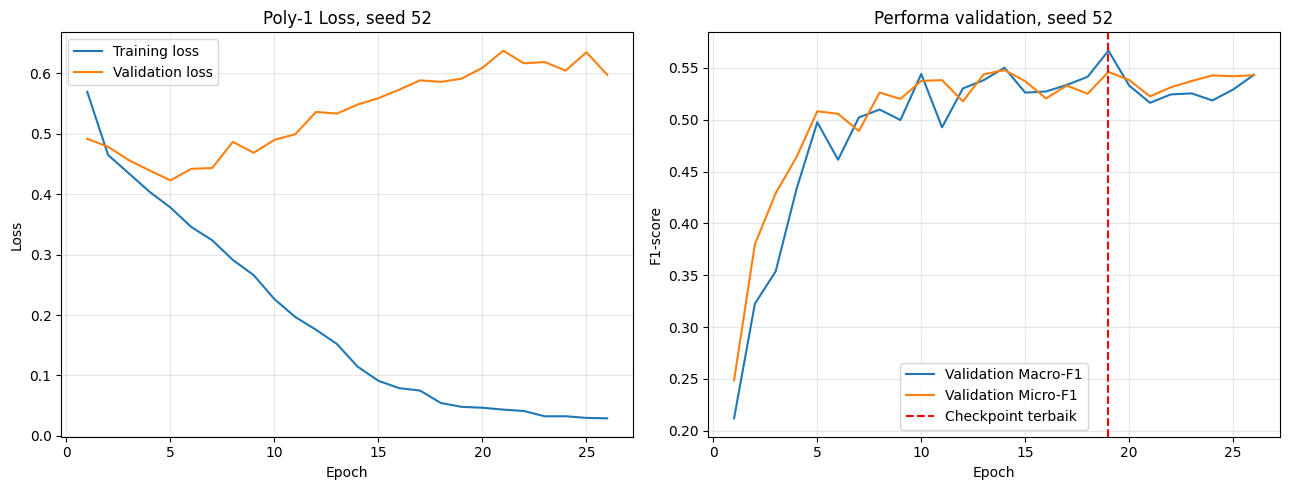

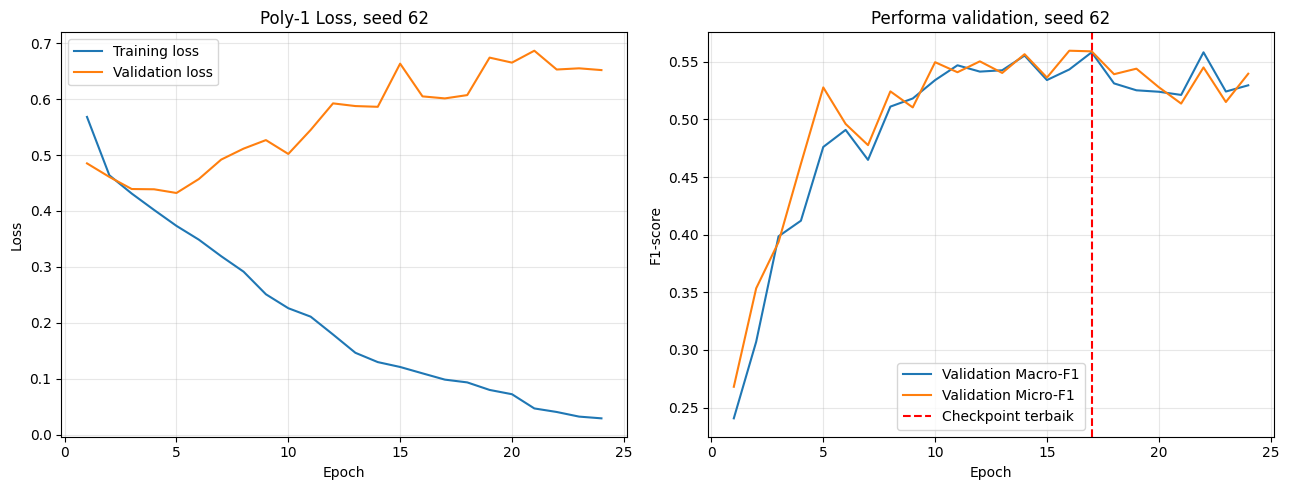

Ringkasan setiap seed:


,loss_function,backbone,seed,poly_epsilon,checkpoint_epoch,validation_macro_f1,test_macro_f1,test_micro_f1,test_six_disease_macro_f1,test_macro_auroc,test_hamming_loss,test_subset_accuracy
0,Poly-1 Loss,ResNet50,52,1.0,19,0.613711,0.599411,0.569466,0.621209,0.846972,0.134286,0.379048
1,Poly-1 Loss,ResNet50,62,1.0,17,0.607853,0.582165,0.589835,0.578601,0.831341,0.136429,0.365714


Ringkasan seed 52 dan 62:


,metric,mean_seed_52_62,std_seed_52_62,minimum,maximum
0,validation_macro_f1,0.610782,0.004142,0.607853,0.613711
1,test_macro_f1,0.590788,0.012195,0.582165,0.599411
2,test_micro_f1,0.579651,0.014404,0.569466,0.589835
3,test_six_disease_macro_f1,0.599905,0.030128,0.578601,0.621209
4,test_macro_auroc,0.839156,0.011053,0.831341,0.846972
5,test_hamming_loss,0.135357,0.001515,0.134286,0.136429
6,test_subset_accuracy,0.372381,0.009428,0.365714,0.379048


Arsip unduhan: /kaggle/working/polyloss_resnet50_multiseed_52_62.zip
- multiseed_aggregate_52_62.csv: 0.71 KB
- multiseed_test_summary.csv: 0.50 KB
- seed_52/best_polyloss_resnet50.pt: 276328.97 KB
- seed_52/best_thresholds.json: 0.64 KB
- seed_52/class_distribution.csv: 0.12 KB
- seed_52/test_metrics_per_label.csv: 0.87 KB
- seed_52/test_predictions.csv: 70.71 KB
- seed_52/test_summary.json: 0.42 KB
- seed_52/training_curves.png: 169.97 KB
- seed_52/training_history.json: 5.85 KB
- seed_62/best_polyloss_resnet50.pt: 276328.97 KB
- seed_62/best_thresholds.json: 0.63 KB
- seed_62/class_distribution.csv: 0.12 KB
- seed_62/test_metrics_per_label.csv: 0.83 KB
- seed_62/test_predictions.csv: 70.23 KB
- seed_62/test_summary.json: 0.42 KB
- seed_62/training_curves.png: 172.15 KB
- seed_62/training_history.json: 5.36 KB


In [4]:
summary_table = pd.DataFrame(
    [evaluation_runs[seed]["summary"] for seed in SEEDS]
).sort_values("seed")

metric_columns = [
    "validation_macro_f1",
    "test_macro_f1",
    "test_micro_f1",
    "test_six_disease_macro_f1",
    "test_macro_auroc",
    "test_hamming_loss",
    "test_subset_accuracy",
]

aggregate_rows = []
for metric in metric_columns:
    values = summary_table[metric].astype(float)
    aggregate_rows.append(
        {
            "metric": metric,
            "mean_seed_52_62": float(values.mean()),
            "std_seed_52_62": float(values.std(ddof=1)),
            "minimum": float(values.min()),
            "maximum": float(values.max()),
        }
    )

aggregate_table = pd.DataFrame(aggregate_rows)
summary_table.to_csv(OUTPUT_DIR / "multiseed_test_summary.csv", index=False)
aggregate_table.to_csv(OUTPUT_DIR / "multiseed_aggregate_52_62.csv", index=False)

for seed in SEEDS:
    history_table = pd.DataFrame(training_runs[seed]["history"])
    best_epoch = training_runs[seed]["best_epoch"]
    figure, axes = plt.subplots(1, 2, figsize=(13, 5))

    axes[0].plot(history_table["epoch"], history_table["train_loss"], label="Training loss")
    axes[0].plot(history_table["epoch"], history_table["validation_loss"], label="Validation loss")
    axes[0].set_title(f"Poly-1 Loss, seed {seed}")
    axes[0].set_xlabel("Epoch")
    axes[0].set_ylabel("Loss")
    axes[0].legend()
    axes[0].grid(alpha=0.3)

    axes[1].plot(
        history_table["epoch"],
        history_table["validation_macro_f1"],
        label="Validation Macro-F1",
    )
    axes[1].plot(
        history_table["epoch"],
        history_table["validation_micro_f1"],
        label="Validation Micro-F1",
    )
    axes[1].axvline(
        best_epoch,
        color="red",
        linestyle="--",
        label="Checkpoint terbaik",
    )
    axes[1].set_title(f"Performa validation, seed {seed}")
    axes[1].set_xlabel("Epoch")
    axes[1].set_ylabel("F1-score")
    axes[1].legend()
    axes[1].grid(alpha=0.3)

    plt.tight_layout()
    plt.savefig(
        training_runs[seed]["seed_dir"] / "training_curves.png",
        dpi=200,
        bbox_inches="tight",
    )
    plt.show()

archive_path = shutil.make_archive(
    "/kaggle/working/polyloss_resnet50_multiseed_52_62",
    "zip",
    root_dir=OUTPUT_DIR,
)

print("Ringkasan setiap seed:")
display(summary_table)
print("Ringkasan seed 52 dan 62:")
display(aggregate_table)
print("Arsip unduhan:", archive_path)

for path in sorted(OUTPUT_DIR.rglob("*")):
    if path.is_file():
        print(f"- {path.relative_to(OUTPUT_DIR)}: {path.stat().st_size / 1024:.2f} KB")
